# Notebook 11 — Random Matrix Theory for 100, 200 and 300 Stocks

## Purpose

This notebook implements the supervisor's suggestion:

- repeat the RMT analysis for 100 stocks;
- repeat it for 200 stocks;
- repeat it for 300 stocks.

We keep the rolling window fixed at 756 trading days so the main changing quantity is the number of stocks.

This is a robustness experiment: does the RMT conclusion remain similar when the matrix becomes larger and noisier?

In [1]:
from pathlib import Path
import sys
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

# Find the project root whether the notebook is launched from:
#   project/
# or:
#   project/notebooks/
CURRENT = Path.cwd().resolve()

if (CURRENT / "data").exists():
    PROJECT_ROOT = CURRENT
elif CURRENT.name == "notebooks" and (CURRENT.parent / "data").exists():
    PROJECT_ROOT = CURRENT.parent
else:
    possible_roots = [CURRENT, *CURRENT.parents]
    matches = [p for p in possible_roots if (p / "data").exists() and (p / "notebooks").exists()]
    if not matches:
        raise FileNotFoundError(
            "Could not find the project root. Open the sp500-forecasting-dissertation "
            "folder in VS Code, then run this notebook again."
        )
    PROJECT_ROOT = matches[0]

DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
REPORT_TABLES = PROJECT_ROOT / "reports" / "tables"
REPORT_FIGURES = PROJECT_ROOT / "reports" / "figures"
MODEL_DIR = PROJECT_ROOT / "reports" / "models"

for folder in [DATA_PROCESSED, REPORT_TABLES, REPORT_FIGURES, MODEL_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Python:", sys.executable)
print("Python version:", sys.version.split()[0])

Project root: /home/claude/project/sp500-forecasting-dissertation
Python: /usr/bin/python3
Python version: 3.12.3


In [2]:
def find_crsp_panel(processed_folder: Path) -> Path:
    """Find the best available corrected CRSP parquet file."""
    preferred_names = [
        "crsp_sp500_daily_corrected_2010_2024.parquet",
        "crsp_sp500_daily_corrected.parquet",
        "crsp_daily_corrected_2010_2024.parquet",
        "crsp_daily_2010_2024.parquet",
    ]

    for name in preferred_names:
        path = processed_folder / name
        if path.exists():
            return path

    candidates = sorted(
        processed_folder.glob("*.parquet"),
        key=lambda p: p.stat().st_mtime,
        reverse=True,
    )

    if not candidates:
        raise FileNotFoundError(
            f"No parquet file was found in {processed_folder}. "
            "Run and save the corrected CRSP data notebook first."
        )

    print("No preferred filename found. Using the newest parquet file:")
    return candidates[0]


PANEL_PATH = find_crsp_panel(DATA_PROCESSED)
panel = pd.read_parquet(PANEL_PATH).copy()
panel.columns = [str(c).strip().lower() for c in panel.columns]

# Accept the possible names used in the earlier audit notebook.
return_candidates = ["ret", "combined_return", "ret_combined"]
return_source = next((c for c in return_candidates if c in panel.columns), None)

required_base = {"permno", "date"}
missing_base = required_base.difference(panel.columns)

if missing_base:
    raise ValueError(f"Missing required columns: {sorted(missing_base)}")

if return_source is None:
    raise ValueError(
        "Could not find a return column. Expected one of: "
        f"{return_candidates}. Found: {panel.columns.tolist()}"
    )

panel["date"] = pd.to_datetime(panel["date"])
panel["permno"] = pd.to_numeric(panel["permno"], errors="coerce").astype("Int64")
panel[return_source] = pd.to_numeric(panel[return_source], errors="coerce")

if "mktcap" in panel.columns:
    panel["mktcap"] = pd.to_numeric(panel["mktcap"], errors="coerce")

panel = (
    panel.dropna(subset=["permno", "date"])
         .sort_values(["date", "permno"])
         .reset_index(drop=True)
)

# IMPORTANT DECISION:
# "simple" keeps CRSP total returns, including a possible -100% delisting return.
# "log" uses log(1 + return), but an exact -100% return cannot be logged.
RETURN_MODE = "simple"

if RETURN_MODE == "simple":
    panel["model_return"] = panel[return_source]
elif RETURN_MODE == "log":
    impossible_for_log = panel[return_source] <= -1
    print("Rows not usable as log-returns:", int(impossible_for_log.sum()))
    panel["model_return"] = np.where(
        panel[return_source] > -1,
        np.log1p(panel[return_source]),
        np.nan,
    )
else:
    raise ValueError("RETURN_MODE must be 'simple' or 'log'.")

print("Loaded:", PANEL_PATH)
print("Rows:", len(panel))
print("Dates:", panel["date"].min(), "to", panel["date"].max())
print("Unique PERMNOs:", panel["permno"].nunique())
print("Return source:", return_source)
print("Return mode:", RETURN_MODE)
print("Missing modelling returns:", panel["model_return"].isna().sum())

Loaded: /home/claude/project/sp500-forecasting-dissertation/data/processed/crsp_sp500_daily_corrected_2010_2024.parquet
Rows: 1711517
Dates: 2010-01-04 00:00:00 to 2024-12-31 00:00:00
Unique PERMNOs: 740
Return source: ret
Return mode: simple
Missing modelling returns: 60


In [3]:
def latest_cross_section_before(data: pd.DataFrame, as_of_date) -> pd.DataFrame:
    """
    Return the cross-section on the latest trading date on or before as_of_date.

    We deliberately do NOT take each stock's individually latest historical row.
    Doing that could accidentally include a company that left the S&P 500 years ago.
    Using one common market date keeps only securities present in the corrected panel
    on that date.
    """
    as_of_date = pd.Timestamp(as_of_date)

    eligible_dates = data.loc[
        data["date"] <= as_of_date,
        "date"
    ]

    if eligible_dates.empty:
        raise ValueError(f"No data available on or before {as_of_date.date()}.")

    market_date = eligible_dates.max()

    cross_section = data.loc[
        data["date"] == market_date
    ].copy()

    if cross_section.empty:
        raise ValueError(f"No cross-section found for {market_date.date()}.")

    return cross_section


def select_top_n_by_lagged_market_cap(
    data: pd.DataFrame,
    as_of_date,
    n_stocks: int,
) -> list[int]:
    """
    Select stocks using market capitalisation from one common historical date.
    """
    if "mktcap" not in data.columns:
        raise ValueError("The panel needs a 'mktcap' column for top-N selection.")

    cross_section = latest_cross_section_before(data, as_of_date)
    cross_section = cross_section.dropna(subset=["mktcap"])
    cross_section = cross_section[cross_section["mktcap"] > 0]

    selected = (
        cross_section.nlargest(n_stocks, "mktcap")["permno"]
                     .astype(int)
                     .tolist()
    )

    if len(selected) < n_stocks:
        print(f"Warning: requested {n_stocks} stocks, but selected {len(selected)}.")

    return selected

## Main mathematical objects

For each universe:

- `N` = number of stocks;
- `T` = number of time observations;
- `q = N / T`;
- Marchenko–Pastur noise boundaries:

\[
\lambda_-=(1-\sqrt q)^2,\qquad
\lambda_+=(1+\sqrt q)^2
\]

Observed eigenvalues inside the theoretical bulk are treated as **noise-like**, not proven noise.

Large eigenvalues above the upper edge may reflect market or sector structure.

In [4]:
ANCHOR_DATE = pd.Timestamp("2019-12-31")
WINDOW_DAYS = 756
UNIVERSE_SIZES = [100, 200, 300]
MIN_COVERAGE = 0.95

print({
    "anchor_date": ANCHOR_DATE,
    "window_days": WINDOW_DAYS,
    "universe_sizes": UNIVERSE_SIZES,
    "minimum_coverage": MIN_COVERAGE,
})

{'anchor_date': Timestamp('2019-12-31 00:00:00'), 'window_days': 756, 'universe_sizes': [100, 200, 300], 'minimum_coverage': 0.95}


## Prepare a clean RMT window

Steps:

1. Use only information dated before the anchor date.
2. Find the previous 756 trading dates.
3. Keep stocks with enough return coverage.
4. Rank eligible stocks by lagged market capitalisation.
5. Standardise each return series.
6. Replace only the small remaining missing fraction with zero **after standardisation**.

After standardisation, zero means that stock's window mean. The number of imputed values is reported and must remain small.

In [5]:
def prepare_rmt_window(
    data: pd.DataFrame,
    anchor_date,
    n_stocks: int,
    window_days: int = 756,
    minimum_coverage: float = 0.95,
):
    anchor_date = pd.Timestamp(anchor_date)

    available_dates = (
        data.loc[data["date"] < anchor_date, "date"]
            .drop_duplicates()
            .sort_values()
    )

    if len(available_dates) < window_days:
        raise ValueError(
            f"Only {len(available_dates)} historical dates are available; "
            f"{window_days} are required."
        )

    window_dates = available_dates.iloc[-window_days:]
    window_start = window_dates.iloc[0]
    window_end = window_dates.iloc[-1]

    window_long = data[
        data["date"].between(window_start, window_end)
    ].copy()

    wide = (
        window_long.pivot_table(
            index="date",
            columns="permno",
            values="model_return",
            aggfunc="first",
        )
        .reindex(window_dates)
    )

    coverage = wide.notna().mean()
    eligible_permnos = coverage[
        coverage >= minimum_coverage
    ].index.astype(int).tolist()

    eligible_data = data[data["permno"].isin(eligible_permnos)]

    selected = select_top_n_by_lagged_market_cap(
        eligible_data,
        as_of_date=window_end,
        n_stocks=n_stocks,
    )

    selected_wide = wide[selected].copy()

    means = selected_wide.mean()
    stds = selected_wide.std()

    # Remove any zero-variance columns before calculating correlations.
    valid_columns = stds[(stds > 0) & stds.notna()].index
    selected_wide = selected_wide[valid_columns]
    means = means[valid_columns]
    stds = stds[valid_columns]

    standardised = (selected_wide - means) / stds

    missing_before = int(standardised.isna().sum().sum())
    total_cells = int(standardised.size)
    missing_fraction = missing_before / total_cells

    standardised = standardised.fillna(0.0)

    information = {
        "window_start": window_start,
        "window_end": window_end,
        "requested_n": n_stocks,
        "actual_n": standardised.shape[1],
        "t_observations": standardised.shape[0],
        "missing_cells_imputed": missing_before,
        "missing_fraction_imputed": missing_fraction,
    }

    return standardised, information

## Eigenvalue decomposition and clipping

Eigenvalue clipping:

- keep signal-like eigenvalues above the upper edge;
- replace noise-like eigenvalues with their average;
- reconstruct the cleaned matrix;
- rescale the diagonal back to one.

In [6]:
def rmt_denoise(standardised_returns: pd.DataFrame):
    values = standardised_returns.to_numpy(dtype=float)
    t_observations, n_assets = values.shape

    correlation = np.corrcoef(values, rowvar=False)

    eigenvalues, eigenvectors = np.linalg.eigh(correlation)
    order = np.argsort(eigenvalues)[::-1]

    eigenvalues = eigenvalues[order]
    eigenvectors = eigenvectors[:, order]

    q = n_assets / t_observations
    lambda_minus = (1 - np.sqrt(q)) ** 2
    lambda_plus = (1 + np.sqrt(q)) ** 2

    noise_mask = eigenvalues <= lambda_plus
    signal_mask = eigenvalues > lambda_plus

    clipped_eigenvalues = eigenvalues.copy()

    if noise_mask.any():
        clipped_eigenvalues[noise_mask] = eigenvalues[noise_mask].mean()

    cleaned = (
        eigenvectors
        @ np.diag(clipped_eigenvalues)
        @ eigenvectors.T
    )

    diagonal_scale = np.sqrt(np.diag(cleaned))
    cleaned_correlation = cleaned / np.outer(diagonal_scale, diagonal_scale)
    np.fill_diagonal(cleaned_correlation, 1.0)

    # Signal-factor scores: time observations projected onto signal eigenvectors.
    signal_vectors = eigenvectors[:, signal_mask]
    signal_factors = values @ signal_vectors

    result = {
        "correlation": correlation,
        "cleaned_correlation": cleaned_correlation,
        "eigenvalues": eigenvalues,
        "clipped_eigenvalues": clipped_eigenvalues,
        "signal_mask": signal_mask,
        "noise_mask": noise_mask,
        "signal_factors": signal_factors,
        "q": q,
        "lambda_minus": lambda_minus,
        "lambda_plus": lambda_plus,
    }

    return result

In [7]:
rmt_results = {}
spectrum_rows = []

for n_stocks in UNIVERSE_SIZES:
    try:
        standardised_window, window_info = prepare_rmt_window(
            panel,
            anchor_date=ANCHOR_DATE,
            n_stocks=n_stocks,
            window_days=WINDOW_DAYS,
            minimum_coverage=MIN_COVERAGE,
        )

        result = rmt_denoise(standardised_window)
        rmt_results[n_stocks] = {
            "window": standardised_window,
            "window_info": window_info,
            "rmt": result,
        }

        spectrum_rows.append({
            "requested_stocks": n_stocks,
            "actual_stocks": window_info["actual_n"],
            "observations": window_info["t_observations"],
            "q": result["q"],
            "lambda_minus": result["lambda_minus"],
            "lambda_plus": result["lambda_plus"],
            "signal_eigenvalues": int(result["signal_mask"].sum()),
            "noise_like_eigenvalues": int(result["noise_mask"].sum()),
            "noise_like_percentage": float(result["noise_mask"].mean()),
            "missing_fraction_imputed": window_info["missing_fraction_imputed"],
        })

    except Exception as error:
        print(f"Universe {n_stocks} failed: {error}")

spectrum_summary = pd.DataFrame(spectrum_rows)
spectrum_summary

,requested_stocks,actual_stocks,observations,q,lambda_minus,lambda_plus,signal_eigenvalues,noise_like_eigenvalues,noise_like_percentage,missing_fraction_imputed
0,100,100,756,0.132275,0.404882,1.859668,7,93,0.930000,0.000000
1,200,200,756,0.264550,0.235861,2.293239,9,191,0.955000,0.000000
2,300,300,756,0.396825,0.136944,2.656707,10,290,0.966667,0.000022


## Plot each spectrum

The vertical line is the Marchenko–Pastur upper noise edge.

As `N` rises while `T` stays fixed:

- `q` rises;
- the theoretical noise bulk widens;
- empirical eigenvalues also change because the underlying stock universe changed.

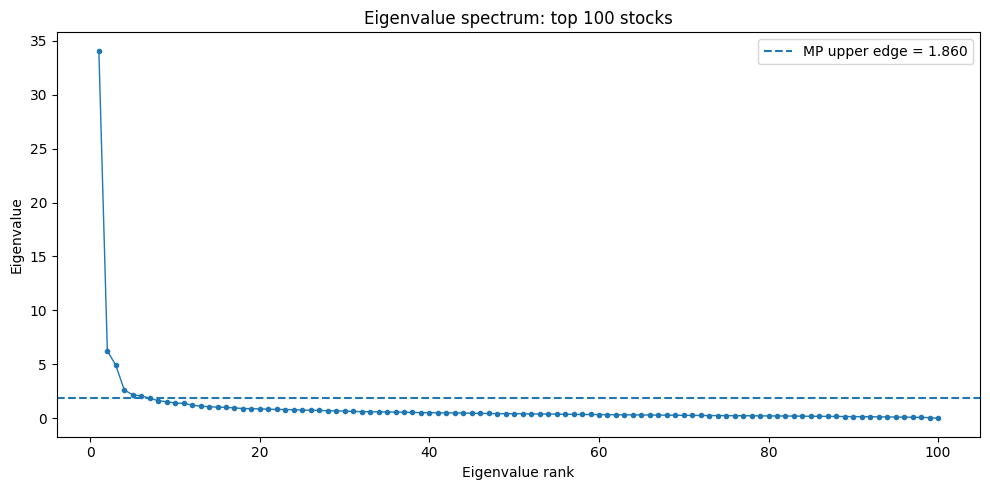

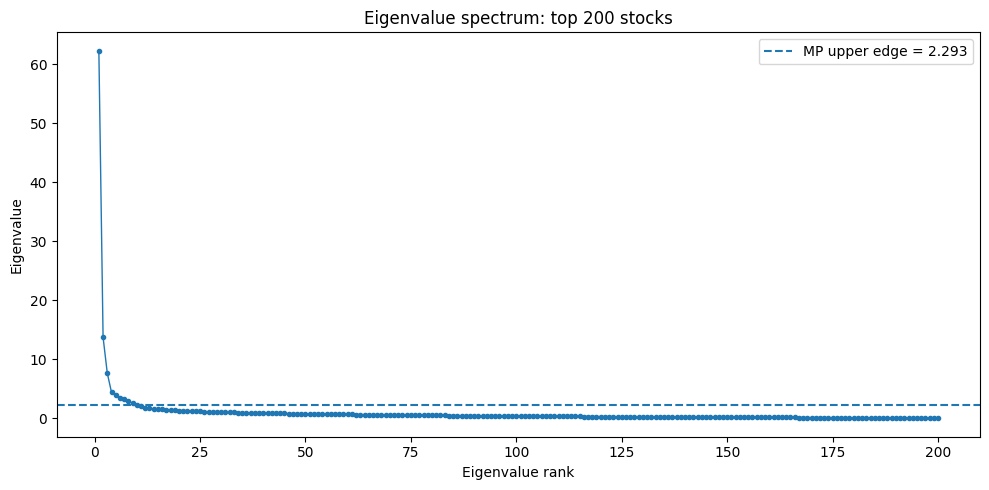

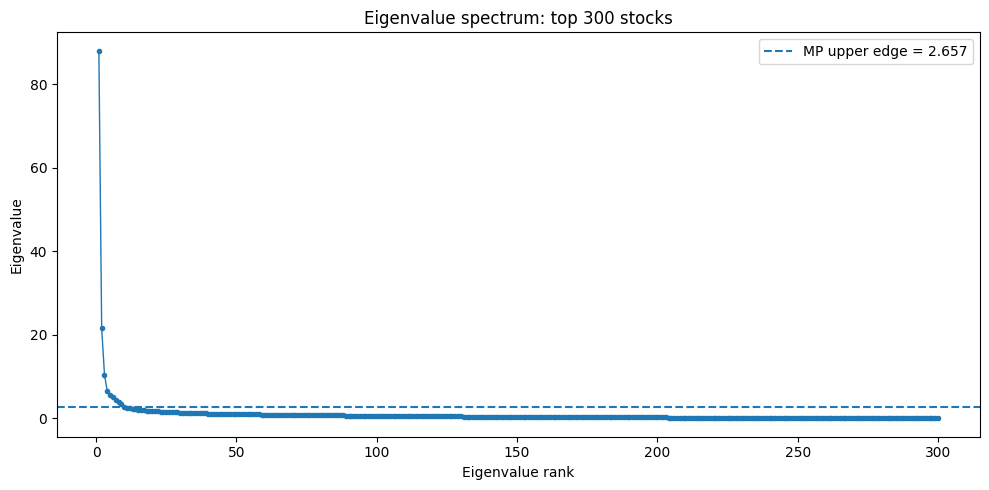

In [8]:
for n_stocks, bundle in rmt_results.items():
    eigenvalues = bundle["rmt"]["eigenvalues"]
    lambda_plus = bundle["rmt"]["lambda_plus"]

    plt.figure(figsize=(10, 5))
    plt.plot(
        np.arange(1, len(eigenvalues) + 1),
        eigenvalues,
        marker="o",
        markersize=3,
        linewidth=1,
    )
    plt.axhline(
        lambda_plus,
        linestyle="--",
        label=f"MP upper edge = {lambda_plus:.3f}",
    )
    plt.title(f"Eigenvalue spectrum: top {n_stocks} stocks")
    plt.xlabel("Eigenvalue rank")
    plt.ylabel("Eigenvalue")
    plt.legend()
    plt.tight_layout()
    plt.savefig('../reports/figures/rmt_eigenvalue_spectrum_100_200_300.png', dpi=150, bbox_inches='tight')
plt.show()

## Save cleaned matrices and factors

These outputs can later be connected to LSTM, GRU and TFT.

- cleaned correlation matrices describe denoised cross-stock relationships;
- signal factors summarise the strongest common movements.

In [9]:
for n_stocks, bundle in rmt_results.items():
    stock_ids = bundle["window"].columns.astype(str)

    cleaned_frame = pd.DataFrame(
        bundle["rmt"]["cleaned_correlation"],
        index=stock_ids,
        columns=stock_ids,
    )

    cleaned_frame.to_parquet(
        DATA_PROCESSED / f"rmt_cleaned_correlation_top_{n_stocks}.parquet"
    )

    factor_values = bundle["rmt"]["signal_factors"]
    factor_columns = [
        f"rmt_factor_{i + 1}"
        for i in range(factor_values.shape[1])
    ]

    factor_frame = pd.DataFrame(
        factor_values,
        index=bundle["window"].index,
        columns=factor_columns,
    )

    factor_frame.to_parquet(
        DATA_PROCESSED / f"rmt_signal_factors_top_{n_stocks}.parquet"
    )

spectrum_summary.to_csv(
    REPORT_TABLES / "rmt_100_200_300_spectrum_summary.csv",
    index=False,
)

print("Saved RMT matrices, factors and spectrum summary.")

Saved RMT matrices, factors and spectrum summary.


## Optional rolling extension

The cell below is deliberately disabled.

After the single-date experiment is understood, repeat the same function every 21 trading days. Save only the summary statistics and factors needed by later models.

Do not begin the full rolling calculation until the single-date results are checked.

In [10]:
RUN_ROLLING_RMT = True

if RUN_ROLLING_RMT:
    eligible_dates = (
        panel.loc[
            panel["date"].between("2013-01-01", "2024-12-31"),
            "date"
        ]
        .drop_duplicates()
        .sort_values()
        .iloc[::21]
    )

    rolling_rows = []

    for anchor_date in eligible_dates:
        for n_stocks in UNIVERSE_SIZES:
            try:
                window, info = prepare_rmt_window(
                    panel,
                    anchor_date=anchor_date,
                    n_stocks=n_stocks,
                    window_days=WINDOW_DAYS,
                    minimum_coverage=MIN_COVERAGE,
                )

                result = rmt_denoise(window)

                rolling_rows.append({
                    "anchor_date": anchor_date,
                    "requested_stocks": n_stocks,
                    "actual_stocks": info["actual_n"],
                    "q": result["q"],
                    "lambda_plus": result["lambda_plus"],
                    "signal_eigenvalues": int(result["signal_mask"].sum()),
                    "noise_like_percentage": float(result["noise_mask"].mean()),
                })

            except Exception as error:
                rolling_rows.append({
                    "anchor_date": anchor_date,
                    "requested_stocks": n_stocks,
                    "error": str(error),
                })

    rolling_rmt_summary = pd.DataFrame(rolling_rows)
    rolling_rmt_summary.to_parquet(
        DATA_PROCESSED / "rolling_rmt_100_200_300_summary.parquet",
        index=False,
    )

    display(rolling_rmt_summary.head())
else:
    print("Rolling RMT is disabled. Set RUN_ROLLING_RMT = True only after checking the single-date results.")

,anchor_date,requested_stocks,error,actual_stocks,q,lambda_plus,signal_eigenvalues,noise_like_percentage
0,2013-01-02,100,Only 754 historical dates are available; 756 a...,NaN,NaN,NaN,NaN,NaN
1,2013-01-02,200,Only 754 historical dates are available; 756 a...,NaN,NaN,NaN,NaN,NaN
2,2013-01-02,300,Only 754 historical dates are available; 756 a...,NaN,NaN,NaN,NaN,NaN
3,2013-02-01,100,NaN,100.0,0.132275,1.859668,4.0,0.960
4,2013-02-01,200,NaN,200.0,0.264550,2.293239,5.0,0.975


## What to say in the meeting

> I use the same 756-day window for 100, 200 and 300 stocks. This lets me study what happens when the number of assets increases while the amount of history is held constant. I am not changing q to make the result look better; q follows from N divided by T. The comparison checks whether RMT denoising is robust to universe size.